# RSA Practical — KEN3170

**Representational Similarity Analysis (RSA)** compares two systems (model ↔ brain) that live in spaces of *different size* and with *arbitrary axes*.
Instead of comparing activations directly, we compare **how each system distinguishes between stimuli**:

1. **Representations** — each system gives one vector per class: array of shape `(n_classes, n_features)`.
2. **RDM** — inside each system, compute the dissimilarity between every pair of classes → `(n_classes, n_classes)` matrix. Same shape for every system, whatever `n_features` is.
3. **Compare RDMs** — correlate the RDMs. High correlation = same *representational geometry*.

RDMs are symmetric with a zero diagonal → only use the **upper triangle without the diagonal** (otherwise pairs are double-counted and the zeros inflate the correlation).

Only `numpy` / `scipy` / `matplotlib` — **no `rsatoolbox`**.

In [24]:
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=3, suppress=True)
DATA_DIR = Path("data")  # run the notebook from inside practical/

## Part I — By hand

Use a calculator for these steps. Write your results in the cell below.

1. RDM per system with the Euclidean distance: $d(\mathbf{x}_i,\mathbf{x}_j)=\sqrt{\sum_k (x_{i,k}-x_{j,k})^2}$
2. Take the 10 unique off-diagonal values per RDM (5·4/2) and compute Pearson $r$ for Model1 vs Brain and Model2 vs Brain.
3. Which model fits better? **Why?** Look at which classes cluster together in each system.

**Part I — solution**

**Step 1: Euclidean distances.** For each pair, subtract the two class vectors element by element, square each difference, sum them, and take the square root. Every system uses only its own vectors, so it doesn't matter that Model1 has 5 dimensions, Model2 has 7 and Brain has 9.

*Worked example, Model1 A–B:*
- difference A − B = [−0.017, 0.023, 0.022, 0.068, −0.028]
- squared = [0.000289, 0.000529, 0.000484, 0.004624, 0.000784]
- sum = 0.006710 → √0.006710 = **0.0819**

Doing the same for all 10 pairs of each system gives the upper triangles of the RDMs:

| pair | Model1 | Model2 | Brain |
|---|---|---|---|
| A-B | 0.0819 | 1.3269 | 0.0950 |
| A-C | 1.3854 | 1.6336 | 1.3651 |
| A-D | 1.3173 | 1.5783 | 1.4196 |
| A-E | 1.2648 | 1.1609 | 1.3974 |
| B-C | 1.4004 | 1.5034 | 1.3677 |
| B-D | 1.3354 | 1.5268 | 1.4017 |
| B-E | 1.2845 | 1.3945 | 1.3800 |
| C-D | 1.3173 | 1.3191 | 1.3701 |
| C-E | 1.3147 | 1.5578 | 1.3593 |
| D-E | 0.0909 | 1.9775 | 0.0528 |
| **mean** | 1.0793 | 1.4979 | 1.1209 |

The full 5×5 RDM mirrors these values across the diagonal, and the diagonal is 0. The diagonal is left out of the comparison because it's 0 in every system and carries no information.

**Step 2: Pearson correlation** between each model's column and the Brain column (m = 10):
1. Center each vector by subtracting its mean.
2. Numerator = Σ (centered model × centered brain).
3. Denominator = √(Σ centered model²) · √(Σ centered brain²).

| | numerator | Σ model² | Σ brain² | r |
|---|---|---|---|---|
| Model1 vs Brain | 2.5958 | 2.4793 | 2.7444 | 2.5958 / √(2.4793·2.7444) = **0.995** |
| Model2 vs Brain | −0.4205 | 0.4449 | 2.7444 | −0.4205 / √(0.4449·2.7444) = **−0.381** |

**Step 3: Conclusion.** **Model1 is the better fit** (r ≈ 0.995 compared with r ≈ −0.381).
- In the Brain, A and B are nearly identical (0.095), D and E are nearly identical (0.053), and every other pair is about 1.4 apart. That makes three clusters: {A,B}, {C}, {D,E}.
- Model1 has exactly the same cluster structure (A-B 0.082, D-E 0.091), so its dissimilarities rise and fall together with the Brain's.
- Model2 spreads all classes roughly evenly (1.16–1.98). It even puts D and E the *farthest* apart (1.98), the opposite of the Brain, which is why its correlation is negative.
- Note that RSA compares **geometry**, not raw activations. If you rotated or reflected Model1's space, its RDM, and so its score, would stay exactly the same.

## Part II — Programmatic RSA

### Step 1: Represent the data
Each system is a `(n_classes, n_features)` array.

In [25]:
model1 = np.array([
    [0.971, 0.04, -0.046, 0.141, -0.159],
    [0.988, 0.017, -0.068, 0.073, -0.131],
    [0.102, 0.155, 0.973, -0.084, 0.09],
    [0.089, 0.992, -0.031, -0.067, -0.072],
    [0.144, 0.975, -0.027, -0.061, -0.142],
])

model2 = np.array([
    [-0.267, -0.215, -0.032, -0.088, -0.189, -0.895, -0.175],
    [0.113, 0.293, 0.401, 0.783, -0.137, -0.26, -0.097],
    [0.932, -0.072, -0.073, -0.188, 0.236, 0.079, 0.089],
    [0.067, -0.087, 0.185, -0.157, -0.179, 0.122, 0.955],
    [-0.13, -0.115, -0.076, -0.042, -0.094, -0.083, -0.979],
])

brain = np.array([
    [0.981, -0.066, -0.045, -0.14, 0.058, 0.005, 0.06, -0.016, -0.095],
    [0.974, -0.042, -0.055, -0.179, 0.05, 0.049, 0.014, 0.035, -0.087],
    [0.1, 0.138, 0.96, -0.084, 0.089, -0.022, -0.096, -0.079, -0.145],
    [0.051, 0.99, -0.099, -0.016, 0.003, -0.067, -0.032, -0.003, -0.086],
    [0.077, 0.986, -0.094, -0.042, 0.013, -0.067, -0.036, -0.037, -0.097],
])

labels = ["A", "B", "C", "D", "E"]
print(model1.shape, model2.shape, brain.shape)

(5, 5) (5, 7) (5, 9)


In [26]:
# Larger synthetic test set (for Steps 2 and 6)
data = np.load(DATA_DIR / "rsa_individual_test_data.npz")
brain_t, model_good, model_bad = data["brain"], data["model_good"], data["model_bad"]
class_labels = data["class_labels"]
benchmark_patterns = data["benchmark_patterns"]

for name in data.files:
    print(f"{name:20s} {data[name].shape}")

class_labels         (12,)
brain                (12, 9)
model_good           (12, 6)
model_bad            (12, 8)
benchmark_patterns   (300, 128)


### Step 2: Compute an RDM

First write it with a **double for-loop** (slow but obvious), then **vectorize** it and benchmark both.

In [27]:
def compute_rdm_loop(patterns: np.ndarray) -> np.ndarray:
    """Euclidean RDM with a double for-loop.
    patterns: (n_classes, n_features) -> returns (n_classes, n_classes)
    """
    n_classes = patterns.shape[0]
    rdm = np.zeros((n_classes, n_classes))
    for i in range(n_classes):
        for j in range(i + 1, n_classes):
            # Compute the Euclidean distance between class i and class j
            distance = np.linalg.norm(patterns[i] - patterns[j])
            rdm[i, j] = distance
            rdm[j, i] = distance  # Symmetric assignment

    return rdm


rdm_m1 = compute_rdm_loop(model1)
print(rdm_m1)

[[0.    0.082 1.385 1.317 1.265]
 [0.082 0.    1.4   1.335 1.284]
 [1.385 1.4   0.    1.317 1.315]
 [1.317 1.335 1.317 0.    0.091]
 [1.265 1.284 1.315 0.091 0.   ]]


In [28]:
def compute_rdm(patterns: np.ndarray, metric: str = "euclidean") -> np.ndarray:
    """Vectorized RDM. metric = "euclidean" or "correlation" (the latter is for Step 6)."""
    patterns = np.asarray(patterns, dtype=float)

    if metric == "euclidean":
        vectorized_rdm = np.sqrt(np.sum((patterns[:, None, :] - patterns[None, :, :]) ** 2, axis=-1))
        return vectorized_rdm

    elif metric == "correlation":
        vectorized_rdm = 1 - np.corrcoef(patterns)
        np.fill_diagonal(vectorized_rdm, 0)
        return vectorized_rdm

    raise ValueError(f"Unknown metric: {metric}")


# Sanity check: loop and vectorized versions must agree
assert np.allclose(compute_rdm_loop(model1), compute_rdm(model1)), "loop and vectorized differ!"
print("loop == vectorized ✔")

loop == vectorized ✔


In [29]:
# Benchmark on the 300 x 128 patterns
t0 = time.perf_counter(); rdm_loop = compute_rdm_loop(benchmark_patterns)
t1 = time.perf_counter(); rdm_vec = compute_rdm(benchmark_patterns)
t2 = time.perf_counter()

print(f"loop:       {t1 - t0:.4f} s")
print(f"vectorized: {t2 - t1:.4f} s   (~{(t1 - t0) / max(t2 - t1, 1e-12):.0f}x faster)")
print("same result:", np.allclose(rdm_loop, rdm_vec))

loop:       0.3408 s
vectorized: 0.0718 s   (~5x faster)
same result: True


### Step 3: Compare two RDMs
Take the Pearson correlation of the **vectorized upper triangles** (`np.triu_indices`, **without** the diagonal).

In [30]:
def upper_triangle(rdm: np.ndarray) -> np.ndarray:
    """Off-diagonal upper-triangular entries as a 1D vector."""
    row_idx, col_idx = np.triu_indices(rdm.shape[0], k=1)
    return rdm[row_idx, col_idx]

def compare_rdms(rdm_a: np.ndarray, rdm_b: np.ndarray, method: str = "pearson") -> float:
    """Correlation between the upper triangles of two RDMs. method = "pearson" | "spearman"."""
    if method == "pearson":
        return stats.pearsonr(upper_triangle(rdm_a), upper_triangle(rdm_b))[0]
    elif method == "spearman":
        return stats.spearmanr(upper_triangle(rdm_a), upper_triangle(rdm_b))[0]
    raise ValueError(f"Unknown method: {method}")


print(len(upper_triangle(compute_rdm(model1))))  # should be 10

10


### Step 4: Apply your functions
Compute the RDMs of `model1`, `model2` and `brain`, then compare each model with the brain. The numbers should match your hand results.

In [31]:
rdm_model1 = compute_rdm(model1)
rdm_model2 = compute_rdm(model2)
rdm_brain  = compute_rdm(brain)

r1 = compare_rdms(rdm_model1, rdm_brain)
r2 = compare_rdms(rdm_model2, rdm_brain)

print(f"r(Model1, Brain) = {r1:.3f}")
print(f"r(Model2, Brain) = {r2:.3f}")
# Matches the hand calculation: ~0.995 and ~-0.381

r(Model1, Brain) = 0.995
r(Model2, Brain) = -0.381


### Step 5: Visualize your RDMs
Plot the three RDMs side by side. Does the visual similarity match the correlation values?

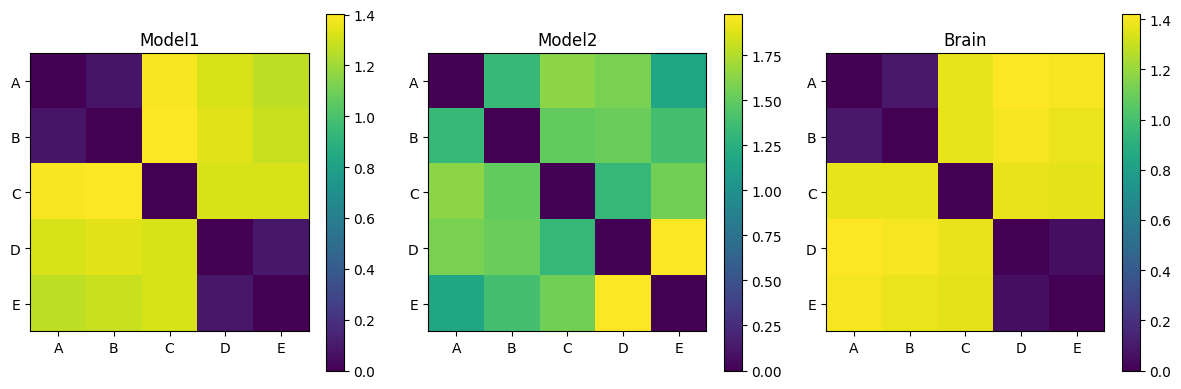

In [32]:
def plot_rdm(rdm, labels=None, title="", ax=None):
    """Heatmap of one RDM. Returns the image object (needed for the colorbar)."""
    if ax is None:
        _, ax = plt.subplots()
    im = ax.imshow(rdm, cmap="viridis")
    if labels is not None:
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
    ax.set_title(title)
    return im

def plot_rdms(rdms: dict, labels=None):
    """Several RDMs side by side. rdms = {"name": rdm}"""
    fig, axes = plt.subplots(1, len(rdms), figsize=(4 * len(rdms), 4))
    for ax, (name, rdm) in zip(axes, rdms.items()):
        im = plot_rdm(rdm, labels=labels, title=name, ax=ax)
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


plot_rdms({"Model1": rdm_model1, "Model2": rdm_model2, "Brain": rdm_brain}, labels)

**Observation:** *(what do you see? Which classes cluster in Brain / Model1 / Model2?)*

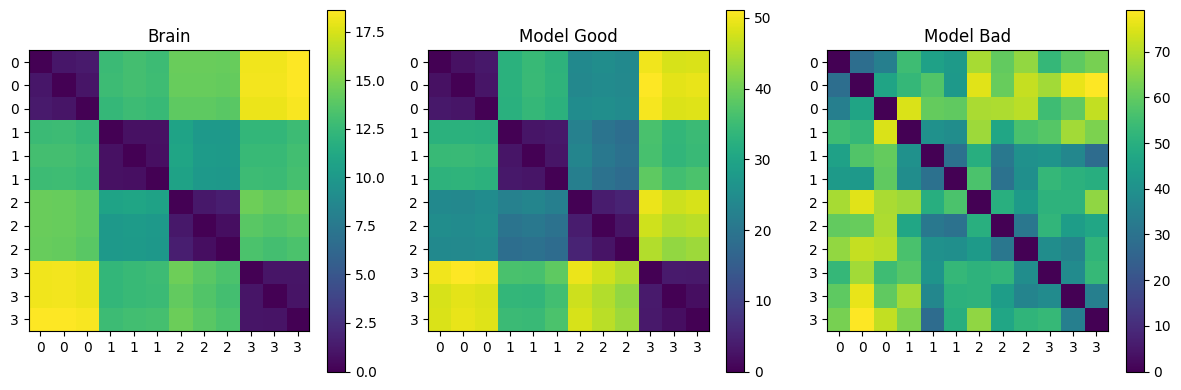

r(Model Good, Brain) = 0.907
r(Model Bad, Brain) = 0.603


In [33]:
# Same thing on the larger test set
rdm_brain_t = compute_rdm(brain_t)
rdm_model_good = compute_rdm(model_good)
rdm_model_bad = compute_rdm(model_bad)

plot_rdms({"Brain": rdm_brain_t, "Model Good": rdm_model_good, "Model Bad": rdm_model_bad}, labels=class_labels)
print(f"r(Model Good, Brain) = {compare_rdms(rdm_model_good, rdm_brain_t):.3f}")
print(f"r(Model Bad, Brain) = {compare_rdms(rdm_model_bad, rdm_brain_t):.3f}")

### Step 6: Generalize your toolbox

You already added `"correlation"` in `compute_rdm` and `"spearman"` in `compare_rdms`. Two things are left:
- `compare_to_many`: rank several candidates against one reference
- Group statistics with confidence intervals

In [34]:
def compare_to_many(reference_rdm, candidate_rdms: dict, method="pearson") -> list:
    """Returns [(name, score), ...] sorted best -> worst."""
    results = [(name, compare_rdms(reference_rdm, rdm, method)) for name, rdm in candidate_rdms.items()]
    return sorted(results, key=lambda t: t[1], reverse=True)

# Try every combination of dissimilarity metric x comparison method
for metric in ["euclidean", "correlation"]:
    for method in ["pearson", "spearman"]:
        ref = compute_rdm(brain_t, metric)
        cands = {"good": compute_rdm(model_good, metric), "bad": compute_rdm(model_bad, metric)}
        print(f"{metric:12s} {method:9s}", compare_to_many(ref, cands, method))

euclidean    pearson   [('good', np.float64(0.906745892763087)), ('bad', np.float64(0.6033561822109574))]
euclidean    spearman  [('good', np.float64(0.8192255505688343)), ('bad', np.float64(0.6234631040601191))]
correlation  pearson   [('good', np.float64(0.8397823613035387)), ('bad', np.float64(0.5056964100228828))]
correlation  spearman  [('good', np.float64(0.7569773510072019)), ('bad', np.float64(0.45241624047594203))]


#### Group statistics

`rsa_group_test_data.npz` contains: `participants` (6 × 12 × 9), `model_a` (10 runs × 12 × 6), `model_b` (10 runs × 12 × 8).

**Plan:**
1. One RDM per participant and one per model run.
2. Score every participant against every run → a `(6, 10)` score matrix per model.
3. **Average over runs** → one score per participant. The *participants* are the independent units (n = 6). The 60 pairs are not independent, so treating them as n = 60 gives a p-value that is too small.
4. Mean + 95% CI across participants.
5. **Paired** test A vs B, because the same participants are compared to both models.

In [35]:
group = np.load(DATA_DIR / "rsa_group_test_data.npz")
participants, model_a, model_b = group["participants"], group["model_a"], group["model_b"]
print(participants.shape, model_a.shape, model_b.shape)

(6, 12, 9) (10, 12, 6) (10, 12, 8)


In [36]:
def mean_ci(scores, confidence=0.95):
    """Returns (mean, ci_low, ci_high)."""
    sem = stats.sem(scores)
    h = sem * stats.t.ppf((1 + confidence) / 2, df=len(scores) - 1)
    return np.mean(scores), np.mean(scores) - h, np.mean(scores) + h

In [37]:
part_rdms = [compute_rdm(subj_data) for subj_data in participants]   # list of 6 RDMs
a_rdms    = [compute_rdm(model_data) for model_data in model_a]   # list of 10 RDMs
b_rdms    = [compute_rdm(model_data) for model_data in model_b]   # list of 10 RDMs

scores_a = np.array([
    [compare_rdms(part_rdm, run_rdm, method="pearson") for run_rdm in a_rdms]
    for part_rdm in part_rdms
])
scores_b = np.array([
    [compare_rdms(part_rdm, run_rdm, method="pearson") for run_rdm in b_rdms]
    for part_rdm in part_rdms
])

per_subj_a = np.mean(scores_a, axis=1)
per_subj_b = np.mean(scores_b, axis=1)

ma, loa, hia = mean_ci(per_subj_a)
mb, lob, hib = mean_ci(per_subj_b)
print(f"Model A: {ma:.3f}  95% CI [{loa:.3f}, {hia:.3f}]")
print(f"Model B: {mb:.3f}  95% CI [{lob:.3f}, {hib:.3f}]")

t_stat, p_value = stats.ttest_rel(per_subj_a, per_subj_b, alternative="greater")
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.2e}")

Model A: 0.858  95% CI [0.806, 0.909]
Model B: 0.484  95% CI [0.455, 0.512]
Paired t-test: t = 29.168, p = 4.44e-07


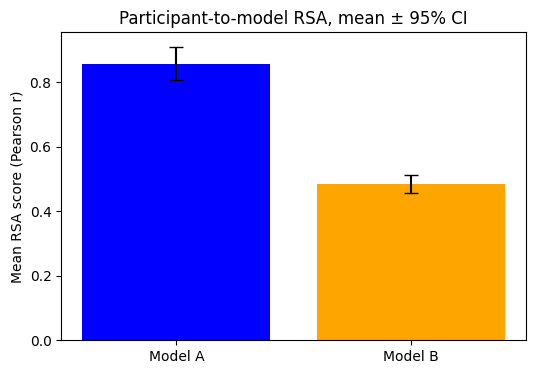

In [38]:
plt.figure(figsize=(6, 4))
plt.bar([0, 1], [ma, mb], yerr=[[ma - loa, mb - lob], [hia - ma, hib - mb]], capsize=5, color=["blue", "orange"])
plt.xticks([0, 1], ["Model A", "Model B"])
plt.ylabel("Mean RSA score (Pearson r)")
plt.title("Participant-to-model RSA, mean ± 95% CI")
plt.show()

**Conclusion:** *(Which model fits better? Is it significant? How wide are the CIs?)*